In [1]:
from pathlib import Path

In [8]:
BASE = Path("./data")

for p in BASE.iterdir():
    print(p)

data/personen.csv
data/verkaeufe.xlsx
data/produkte.json
data/sensoren.csv


In [9]:
path = BASE / "personen.csv"

with open(path, "r") as f:
    lines = f.readlines()

print(lines)

['name,alter,stadt,studienfach\n', 'Anna,23,Wien,Informatik\n', 'Ben,30,Graz,Maschinenbau\n', 'Clara,25,Linz,Design\n', 'David,28,Wien,Informatik\n', 'Ella,22,Salzburg,Physik\n']


In [11]:
header = lines[0].strip().split(",")
header

['name', 'alter', 'stadt', 'studienfach']

In [16]:
daten = []
for line in lines[1:]:
    values = line.strip().split(",")
    daten.append(dict(zip(header, values)))
daten

[{'name': 'Anna', 'alter': '23', 'stadt': 'Wien', 'studienfach': 'Informatik'},
 {'name': 'Ben',
  'alter': '30',
  'stadt': 'Graz',
  'studienfach': 'Maschinenbau'},
 {'name': 'Clara', 'alter': '25', 'stadt': 'Linz', 'studienfach': 'Design'},
 {'name': 'David',
  'alter': '28',
  'stadt': 'Wien',
  'studienfach': 'Informatik'},
 {'name': 'Ella', 'alter': '22', 'stadt': 'Salzburg', 'studienfach': 'Physik'}]

In [18]:
daten[0]["name"]

'Anna'

In [21]:
anzahl_wien = sum([1 for r in daten if r["stadt"] == "Wien"])
anzahl_wien

2

# CSV


In [22]:
import csv

with open(path, "r") as f:
    reader = csv.DictReader(f)
    daten = list(reader)
daten

[{'name': 'Anna', 'alter': '23', 'stadt': 'Wien', 'studienfach': 'Informatik'},
 {'name': 'Ben',
  'alter': '30',
  'stadt': 'Graz',
  'studienfach': 'Maschinenbau'},
 {'name': 'Clara', 'alter': '25', 'stadt': 'Linz', 'studienfach': 'Design'},
 {'name': 'David',
  'alter': '28',
  'stadt': 'Wien',
  'studienfach': 'Informatik'},
 {'name': 'Ella', 'alter': '22', 'stadt': 'Salzburg', 'studienfach': 'Physik'}]

# NUMPY

In [23]:
import numpy as np

path = BASE / "sensoren.csv"

arr1 = np.loadtxt(path, delimiter=",", skiprows=1)
arr1

array([[ 0.  , 22.4 ,  0.65],
       [ 1.  , 22.5 ,  0.66],
       [ 2.  , 22.7 ,  0.66],
       [ 3.  , 22.9 ,  0.67],
       [ 4.  , 23.  ,  0.68]])

In [25]:
arr2 = np.genfromtxt(path, delimiter=",", names=True)
arr2

array([(0., 22.4, 0.65), (1., 22.5, 0.66), (2., 22.7, 0.66),
       (3., 22.9, 0.67), (4., 23. , 0.68)],
      dtype=[('zeit', '<f8'), ('temp_c', '<f8'), ('feuchte_rel', '<f8')])

In [26]:
print(arr2.dtype.names)
print(arr2[0])

('zeit', 'temp_c', 'feuchte_rel')
(0.0, 22.4, 0.65)


In [27]:
arr2["temp_c"]

array([22.4, 22.5, 22.7, 22.9, 23. ])

In [28]:
arr2["temp_c"].mean()

np.float64(22.7)

# Matplotlib

In [30]:
import matplotlib.pyplot as plt

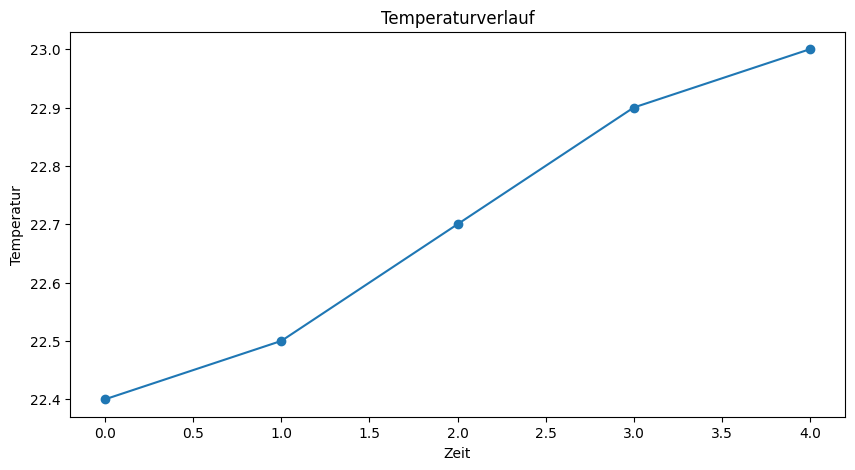

In [34]:
x = arr2["zeit"]
y = arr2["temp_c"]

plt.figure(figsize=(10,5))
plt.plot(x,y, marker="o")
plt.xlabel("Zeit")
plt.ylabel("Temperatur")
plt.title("Temperaturverlauf")

plt.show()